# Mixture Density Networks con PyTorch

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana04_MDN.ipynb)

En esta notebook vamos a construir una **Mixture Density Network (MDN)** para modelar la distribución condicional de la **sensación térmica** a partir de variables meteorológicas.

Trabajaremos con el dataset de ejemplo:

`weather_dataset_example.csv`

Objetivos de aprendizaje:

- entender qué significa modelar una distribución condicional `p(y|x)`;
- implementar una MDN en PyTorch;
- entrenar el modelo maximizando verosimilitud;
- interpretar medias, desvíos y pesos de mezcla.


## Introducción

En una regresión estándar, una red neuronal suele devolver **un único valor** para cada entrada `x`.

Una MDN, en cambio, devuelve los parámetros de una **mezcla de gaussianas**:

$$
p(y\mid x)=\sum_{k=1}^{K}\pi_k(x)\,\mathcal N\big(y\mid \mu_k(x),\sigma_k^2(x)\big).
$$

Para cada dato de entrada, la red aprende:

- $K$ pesos de mezcla $\pi_k(x)$ que suman 1;
- $K$ medias $\mu_k(x)$;
- $K$ desvíos estándar $\sigma_k(x) > 0$.

Esto permite describir situaciones donde una misma entrada puede estar asociada a **varios valores plausibles** de salida, o donde la incertidumbre cambia con $x$.

- en la fórmula de la gaussiana, la dimensión $c$ es la dimensión de la variable de salida, no un valor fijo igual a 2;
- para que $\pi_k$ sume 1 usamos `softmax`.
- para forzar $\sigma_k > 0$ usaremos `softplus` en lugar de `exp`, porque suele ser más estable numéricamente.


In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")


Dispositivo: cpu


## Carga de datos

El dataset contiene 7 variables meteorológicas:

- `temperature`
- `apparent_temperature`
- `humidity`
- `wind_speed`
- `wind_bearing`
- `visibility`
- `pressure`

Vamos a usar como objetivo la variable `apparent_temperature` y como entradas las otras 6 columnas.


In [29]:
url = "https://raw.githubusercontent.com/pandego/mdn-playground/refs/heads/main/data/01_raw/weather_dataset/weather_dataset_example.csv"

data = pd.read_csv(url, delimiter=";")
print(data.shape)
data.head()


(96453, 7)


,temperature,apparent_temperature,humidity,wind_speed,wind_bearing,visibility,pressure
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51


In [ ]:
print("Valores faltantes por columna:")
display(data.isna().sum().to_frame("faltantes").T)
display(data.describe())


Valores faltantes por columna:


,temperature,apparent_temperature,humidity,wind_speed,wind_bearing,visibility,pressure
faltantes,0,0,0,0,0,0,0


,temperature,apparent_temperature,humidity,wind_speed,wind_bearing,visibility,pressure
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,1046.380000


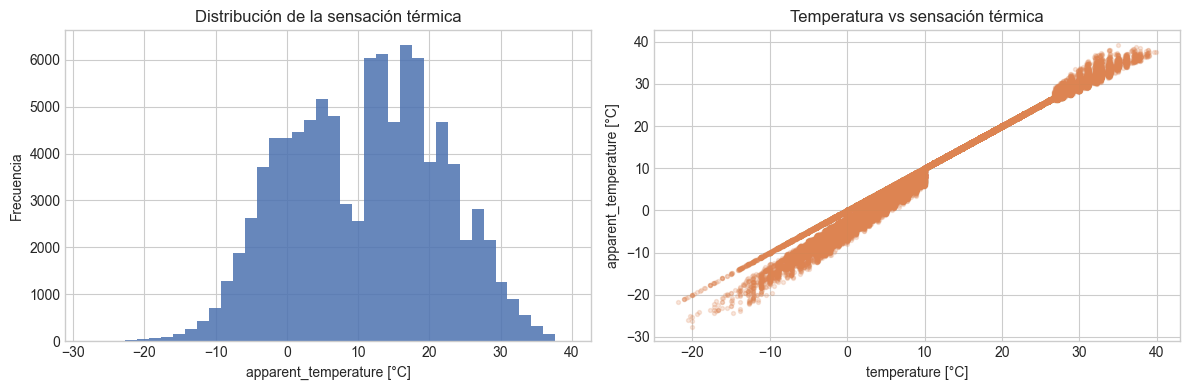

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data["apparent_temperature"], bins=40, color="#4C72B0", alpha=0.85)
axes[0].set_title("Distribución de la sensación térmica")
axes[0].set_xlabel("apparent_temperature [°C]")
axes[0].set_ylabel("Frecuencia")

axes[1].scatter(
    data["temperature"],
    data["apparent_temperature"],
    s=8,
    alpha=0.2,
    color="#DD8452",
)
axes[1].set_title("Temperatura vs sensación térmica")
axes[1].set_xlabel("temperature [°C]")
axes[1].set_ylabel("apparent_temperature [°C]")

plt.tight_layout()
plt.show()


## Separación en entrenamiento, validación y prueba

Vamos a separar los datos y luego estandarizarlos . La secuencia que haremos sera

1. separar `train`, `validation` y `test`;
2. calcular media y desvío estándar usando sólo `train`;
3. estandarizar `validation` y `test` con esas mismas estadísticas.

Además, también vamos a estandarizar la variable objetivo `y`, porque en MDN esto suele ayudar bastante a la estabilidad numérica.


In [ ]:
feature_cols = [c for c in data.columns if c != "apparent_temperature"]
target_col = "apparent_temperature"

print(f"Características: {feature_cols}")
X = torch.tensor(data[feature_cols].to_numpy(dtype=np.float32))
y = torch.tensor(data[[target_col]].to_numpy(dtype=np.float32))


def compute_standardization_stats(tensor):
    mean = tensor.mean(dim=0, keepdim=True)
    std = tensor.std(dim=0, unbiased=False, keepdim=True)
    std = torch.where(std < 1e-6, torch.ones_like(std), std)
    return mean, std


def standardize(tensor, mean, std):
    return (tensor - mean) / std

def destandardize(tensor, mean, std):
    return tensor * std + mean


num_samples = X.shape[0]
perm = torch.randperm(num_samples)

n_train = int(0.70 * num_samples)
n_val = int(0.20 * num_samples)

train_idx = perm[:n_train]
val_idx = perm[n_train:n_train + n_val]
test_idx = perm[n_train + n_val:]

X_train_raw, y_train_raw = X[train_idx], y[train_idx]
X_val_raw, y_val_raw = X[val_idx], y[val_idx]
X_test_raw, y_test_raw = X[test_idx], y[test_idx]

x_mean, x_std = compute_standardization_stats(X_train_raw)
y_mean, y_std = compute_standardization_stats(y_train_raw)

X_train = standardize(X_train_raw, x_mean, x_std)
X_val = standardize(X_val_raw, x_mean, x_std)
X_test = standardize(X_test_raw, x_mean, x_std)

y_train = standardize(y_train_raw, y_mean, y_std)
y_val = standardize(y_val_raw, y_mean, y_std)
y_test = standardize(y_test_raw, y_mean, y_std)

print(f"Train: {tuple(X_train.shape)}, {tuple(y_train.shape)}")
print(f"Val:   {tuple(X_val.shape)}, {tuple(y_val.shape)}")
print(f"Test:  {tuple(X_test.shape)}, {tuple(y_test.shape)}")


Características: ['temperature', 'humidity', 'wind_speed', 'wind_bearing', 'visibility', 'pressure']
Train: (67517, 6), (67517, 1)
Val:   (19290, 6), (19290, 1)
Test:  (9646, 6), (9646, 1)


## Dataset y DataLoaders

Definimos un `Dataset` simple para usar los datos con PyTorch.


In [48]:
batch_size = 256

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batches de entrenamiento: {len(train_loader)}")


Batches de entrenamiento: 264


## Implementación de la MDN

La red tendrá un tronco MLP y tres cabezas de salida:

- `logits_pi`: pesos de mezcla antes de aplicar `softmax`;
- `mu`: medias de cada componente;
- `sigma`: desvíos estándar positivos.

En esta notebook usamos una salida unidimensional (`y` es la sensación térmica), pero el código está preparado para extenderse a salidas de mayor dimensión.


In [7]:
class MDN(nn.Module):
    def __init__(self, dim_entrada, dim_salida=1, num_mezclas=5, num_ocultas=64):
        super().__init__()
        self.dim_salida = dim_salida
        self.num_mezclas = num_mezclas

        self.backbone = nn.Sequential(
            nn.Linear(dim_entrada, num_ocultas),
            nn.ReLU(),
            nn.Linear(num_ocultas, num_ocultas),
            nn.ReLU(),
        )

        self.pi_head = nn.Linear(num_ocultas, num_mezclas)
        self.mu_head = nn.Linear(num_ocultas, num_mezclas * dim_salida)
        self.sigma_head = nn.Linear(num_ocultas, num_mezclas * dim_salida)

    def forward(self, x):
        h = self.backbone(x)
        logits_pi = self.pi_head(h)
        mu = self.mu_head(h).view(-1, self.num_mezclas, self.dim_salida)
        sigma = torch.nn.functional.softplus(
            self.sigma_head(h)
        ).view(-1, self.num_mezclas, self.dim_salida) + 1e-3
        return logits_pi, mu, sigma


## 6. Función de costo: negativo de la log-verosimilitud

Queremos maximizar la verosimilitud del modelo. Equivalente a eso, minimizamos el **negativo del logaritmo de la verosimilitud**.

Una implementación ingenua podría calcular probabilidades, exponenciales y logaritmos por separado, pero eso suele ser inestable. En cambio, usamos una versión basada en `logsumexp`, que es mucho más robusta.

Si `y` es un escalar, la pérdida para un batch es

$$
\mathcal L = -\frac{1}{B}\sum_{b=1}^{B}\log\left(\sum_{k=1}^{K}\pi_k(x_b)\,\mathcal N(y_b\mid \mu_k(x_b),\sigma_k^2(x_b))\right).
$$


In [49]:
def mdn_nll(logits_pi, mu, sigma, y):
    """
    logits_pi: [B, K]
    mu:        [B, K, D]
    sigma:     [B, K, D]
    y:         [B, D]
    """
    y = y.unsqueeze(1).expand_as(mu)
    comp = torch.distributions.Normal(loc=mu, scale=sigma)
    comp_log_prob = comp.log_prob(y).sum(dim=-1)  # [B, K]
    log_pi = torch.log_softmax(logits_pi, dim=-1)
    log_prob = torch.logsumexp(log_pi + comp_log_prob, dim=-1)
    return -log_prob.mean()


def mdn_mean(logits_pi, mu):
    pi = torch.softmax(logits_pi, dim=-1).unsqueeze(-1)
    return (pi * mu).sum(dim=1)


def mdn_sample(logits_pi, mu, sigma):
    pi = torch.softmax(logits_pi, dim=-1)
    cat = torch.distributions.Categorical(probs=pi)
    k = cat.sample()
    batch_idx = torch.arange(mu.size(0), device=mu.device)
    mu_k = mu[batch_idx, k]
    sigma_k = sigma[batch_idx, k]
    normal = torch.distributions.Normal(mu_k, sigma_k)
    return normal.sample()


## 7. Entrenamiento

Usaremos:

- optimizador `Adam`;
- validación al final de cada época;
- `early stopping` para quedarnos con el mejor modelo en validación;
- `gradient clipping` para evitar gradientes demasiado grandes.


In [50]:
model = MDN(dim_entrada=X_train.shape[1], dim_salida=1, num_mezclas=5, num_ocultas=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

num_epocas = 40
patience = 8
mejor_val = float("inf")
mejor_estado = None
espera = 0

hist_train = []
hist_val = []

for epoca in range(1, num_epocas + 1):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits_pi, mu, sigma = model(xb)
        loss = mdn_nll(logits_pi, mu, sigma, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)
    hist_train.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits_pi, mu, sigma = model(xb)
            loss = mdn_nll(logits_pi, mu, sigma, yb)
            val_loss += loss.item() * xb.size(0)

    val_loss /= len(val_loader.dataset)
    hist_val.append(val_loss)

    if val_loss < mejor_val - 1e-4:
        mejor_val = val_loss
        mejor_estado = model.state_dict().copy()
        espera = 0
    else:
        espera += 1

    if epoca == 1 or epoca % 5 == 0:
        print(f"Época {epoca:02d} | train NLL = {train_loss:.4f} | val NLL = {val_loss:.4f}")

    if espera >= patience:
        print(f"Early stopping en la época {epoca}.")
        break

if mejor_estado is not None:
    model.load_state_dict(mejor_estado)


Época 01 | train NLL = -0.5757 | val NLL = -1.3810
Época 05 | train NLL = -2.0708 | val NLL = -2.0887
Época 10 | train NLL = -2.4883 | val NLL = -2.6847
Época 15 | train NLL = -2.8762 | val NLL = -2.9283
Época 20 | train NLL = -3.1255 | val NLL = -2.3419
Época 25 | train NLL = -3.2266 | val NLL = -3.2799
Época 30 | train NLL = -3.2861 | val NLL = -3.0767
Época 35 | train NLL = -3.3690 | val NLL = -3.5572
Early stopping en la época 35.


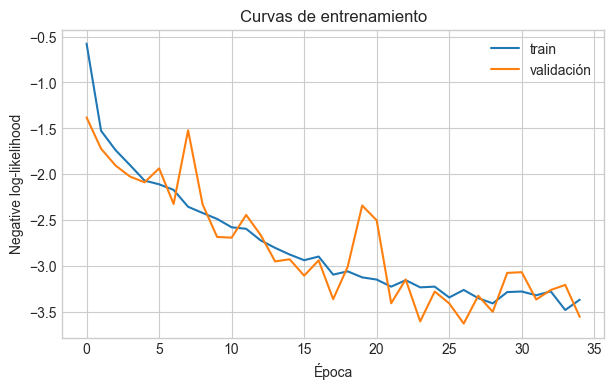

In [51]:
plt.figure(figsize=(7, 4))
plt.plot(hist_train, label="train")
plt.plot(hist_val, label="validación")
plt.xlabel("Época")
plt.ylabel("Negative log-likelihood")
plt.title("Curvas de entrenamiento")
plt.legend()
plt.show()


## 8. Evaluación sobre el conjunto de prueba

Hay varias maneras de resumir la predicción de una MDN.

Dos opciones frecuentes son:

- **media condicional**: `E[y|x] = \sum_k \pi_k \mu_k`;
- **muestra** de la mezcla: primero elegimos una componente según `\pi`, luego muestreamos una normal.

La media condicional es útil si queremos comparar contra una regresión clásica. La muestra es útil si queremos generar salidas plausibles de acuerdo con la incertidumbre del modelo.


In [52]:
model.eval()

y_true_scaled = []
y_pred_mean_scaled = []
y_pred_sample_scaled = []
test_nll = 0.0

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits_pi, mu, sigma = model(xb)
        loss = mdn_nll(logits_pi, mu, sigma, yb)
        test_nll += loss.item() * xb.size(0)

        y_mean_pred = mdn_mean(logits_pi, mu)
        y_sample_pred = mdn_sample(logits_pi, mu, sigma)

        y_true_scaled.append(yb.cpu())
        y_pred_mean_scaled.append(y_mean_pred.cpu())
        y_pred_sample_scaled.append(y_sample_pred.cpu())

test_nll /= len(test_loader.dataset)

y_true_scaled = torch.cat(y_true_scaled, dim=0)
y_pred_mean_scaled = torch.cat(y_pred_mean_scaled, dim=0)
y_pred_sample_scaled = torch.cat(y_pred_sample_scaled, dim=0)

y_true = destandardize(y_true_scaled, y_mean, y_std).numpy().ravel()
y_pred_mean = destandardize(y_pred_mean_scaled, y_mean, y_std).numpy().ravel()
y_pred_sample = destandardize(y_pred_sample_scaled, y_mean, y_std).numpy().ravel()

rmse = np.sqrt(np.mean((y_true - y_pred_mean) ** 2))
mae = np.mean(np.abs(y_true - y_pred_mean))

print(f"Test NLL (escala estandarizada): {test_nll:.4f}")
print(f"RMSE usando la media condicional: {rmse:.3f} °C")
print(f"MAE  usando la media condicional: {mae:.3f} °C")


Test NLL (escala estandarizada): -3.5570
RMSE usando la media condicional: 0.230 °C
MAE  usando la media condicional: 0.117 °C


Observación: la NLL puede resultar incluso negativa. Eso **no es un error**. Las densidades continuas no están acotadas por 1, así que su logaritmo puede ser positivo en algunas regiones.


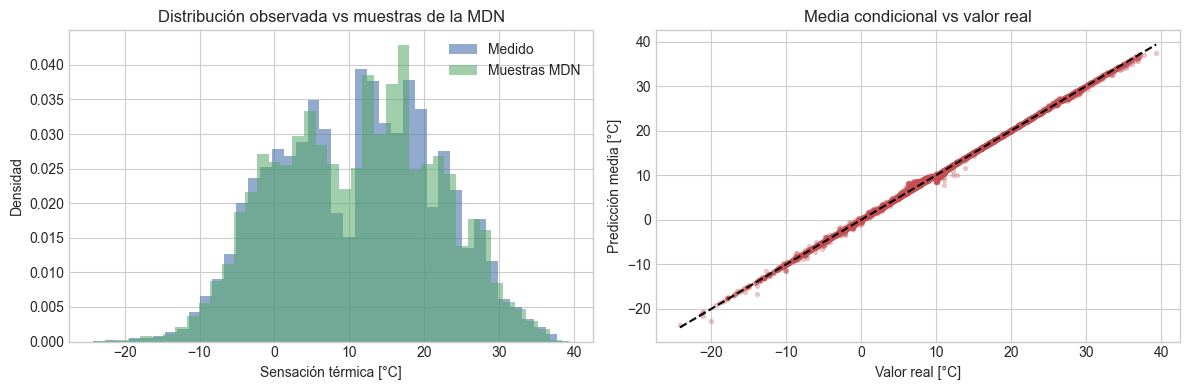

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_true, bins=40, density=True, alpha=0.60, label="Medido", color="#4C72B0")
axes[0].hist(y_pred_sample, bins=40, density=True, alpha=0.55, label="Muestras MDN", color="#55A868")
axes[0].set_title("Distribución observada vs muestras de la MDN")
axes[0].set_xlabel("Sensación térmica [°C]")
axes[0].set_ylabel("Densidad")
axes[0].legend()

axes[1].scatter(y_true, y_pred_mean, s=8, alpha=0.25, color="#C44E52")
mn = min(y_true.min(), y_pred_mean.min())
mx = max(y_true.max(), y_pred_mean.max())
axes[1].plot([mn, mx], [mn, mx], color="black", linestyle="--")
axes[1].set_title("Media condicional vs valor real")
axes[1].set_xlabel("Valor real [°C]")
axes[1].set_ylabel("Predicción media [°C]")

plt.tight_layout()
plt.show()


## 9. Mirar la distribución condicional para un caso particular

Uno de los beneficios de una MDN es que podemos inspeccionar la **densidad completa** `p(y|x)` y no solamente un valor puntual.

En la siguiente celda elegimos un ejemplo del conjunto de prueba, recuperamos los parámetros de la mezcla y dibujamos la densidad aprendida en función de `y`.


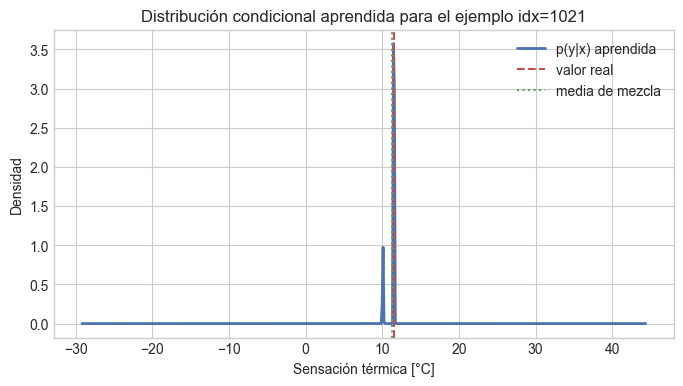

Pesos de mezcla: [0.149 0.    0.001 0.85  0.   ]
Medias de las componentes [°C]: [10.076  9.603  9.805 11.512 10.431]
Desvíos estándar [°C]: [0.053 0.097 0.909 0.053 2.672]
Valor real [°C]: 11.533


In [111]:
def mixture_pdf_1d(y_values, logits_pi, mu, sigma):
    pi = torch.softmax(logits_pi, dim=-1).cpu().numpy().reshape(-1)
    mu = mu.cpu().numpy().reshape(-1)
    sigma = sigma.cpu().numpy().reshape(-1)

    dens = np.zeros_like(y_values, dtype=np.float64)
    norm_const = np.sqrt(2.0 * np.pi)
    for peso, media, desv in zip(pi, mu, sigma):
        dens += peso * np.exp(-0.5 * ((y_values - media) / desv) ** 2) / (norm_const * desv)
    return dens


idx = np.random.choice(len(X_test))
x_example = X_test[idx:idx + 1].to(device)
y_example_real = destandardize(y_test[idx:idx + 1], y_mean, y_std).item()

with torch.no_grad():
    logits_pi_ex, mu_ex_scaled, sigma_ex_scaled = model(x_example)

pi_ex = torch.softmax(logits_pi_ex, dim=-1).squeeze(0).cpu().numpy()
mu_ex = destandardize(mu_ex_scaled.squeeze(0).cpu(), y_mean, y_std).numpy()
sigma_ex = (sigma_ex_scaled.squeeze(0).cpu() * y_std).numpy()

mu_ex_t = torch.tensor(mu_ex, dtype=torch.float32).unsqueeze(0)
sigma_ex_t = torch.tensor(sigma_ex, dtype=torch.float32).unsqueeze(0)
logits_ex_t = torch.log(torch.tensor(pi_ex, dtype=torch.float32)).unsqueeze(0)

y_grid = np.linspace(y_true.min() - 5, y_true.max() + 5, 600)
pdf = mixture_pdf_1d(y_grid, logits_ex_t, mu_ex_t, sigma_ex_t)

plt.figure(figsize=(8, 4))
plt.plot(y_grid, pdf, color="#4C72B0", linewidth=2, label="p(y|x) aprendida")
plt.axvline(y_example_real, color="#C44E52", linestyle="--", label="valor real")
plt.axvline((pi_ex[:, None] * mu_ex).sum(), color="#55A868", linestyle=":", label="media de mezcla")
plt.xlabel("Sensación térmica [°C]")
plt.ylabel("Densidad")
plt.title(f"Distribución condicional aprendida para el ejemplo idx={idx}")
plt.legend()
plt.show()

print("Pesos de mezcla:", np.round(pi_ex, 3))
print("Medias de las componentes [°C]:", np.round(mu_ex.ravel(), 3))
print("Desvíos estándar [°C]:", np.round(sigma_ex.ravel(), 3))
print("Valor real [°C]:", round(y_example_real, 3))
